# BTC N-convergence — **corrected diffusive solver**

Plotting-only companion to `../convergence_check.ipynb`, for the resampled
campaign in this bundle.

This bundle carries a single collective scheme, the diffusion-completed one,
with the corrected **Stratonovich** drift
(`btc.sde.collective_diffusive_drift_cartesian`): the full-Γ collective field
plus the drive, and nothing else.  The drift-only and `diffusive_em` variants
have been removed here (`../btc_fixed/` still has all three).  The pre-fix
solver applied the
Itô→Stratonovich conversion twice — once implicitly through the chain-rule map
of the (θ,φ) Itô drift, once explicitly as `+½κ(sₓ, s_y, 2s_z)` — which added a
spurious tangential drift toward the equator.  `../N_convergence_cluster/` is
the untouched pre-fix bundle, kept for comparison.

**The semiclassical data must be regenerated with this bundle's solver**; the
exact/deterministic reference in `deterministic_qfi/` is solver-independent and
was carried over unchanged.  Until the new runs land in
`semiclassical_qfi_powersums_ratio_2/`, both cells plot the exact curves alone.

```bash
python3 sc_plan.py --n-traj 20000 --N 128 256 512      # size the SLURM array
# ... run sc_run_batches.py / sc_run_batches.sh into
#     semiclassical_qfi_powersums_ratio_2/dt_001
python3 sc_aggregate.py --dir semiclassical_qfi_powersums_ratio_2/dt_001
```

Cell 1 — dt convergence at fixed N.  Cell 2 — N convergence, dynamics + cuts.


semiclassical N: [2, 4, 8, 16, 32, 64, 128, 256]
deterministic N: [2, 4, 8, 16, 32, 64, 128, 256, 512]
fit |Δ| = a N^b at κt=100: a=5.17+-0.191, b=-1.55+-0.0445


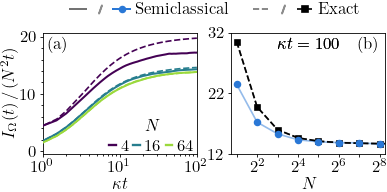

kappa*t=100:  N=256  semiclassical=3.400, exact=3.417


In [5]:
import sys, pathlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# Repository-wide SciencePlots figure style (../plotstyle.py): REVTeX geometry,
# Computer Modern at 10 pt, outward ticks.  Everything else about this figure is
# set in the knob block below.
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root: ../../plotstyle.py
from plotstyle import COLUMN_WIDTH, TEXT_WIDTH, PALETTE, figsize, limit_ticks, use_style

use_style()          # use_style(latex=False) → same look without a LaTeX install

# ── N-convergence of the collective-BTC QFI: dynamics + fixed-time cuts ────
# The semiclassical (diffusive DTWA) and deterministic (exact) runs live
# as one npz per N in their own folder, with independent — possibly different —
# sets of N.  Each folder is loaded into a dict keyed by N and whatever is
# present gets plotted, so the figure stays correct as more N land.
#
# Panel (a) shows the time-resolved QFI rate F_Q/(S² t) per N (semiclassical
# solid, exact dashed, same colour = same N); panels (b)-(d) cut through that
# dynamics at fixed κt and read the N-convergence there.  The cuts matter
# because DTWA's 1/S-suppressed error grows secularly in t and the two limits do
# not commute: at fixed t it converges to the exact result as N→∞, whereas at
# fixed N it degrades as t→∞.  Expected — and observed — story: at early κt the
# semiclassical meets the exact thermodynamic plateau across all N; at late κt
# the large-N points peel below it.
# ═══ Figure knobs — everything about this figure is set right here ═══════════
SC_DIR   = Path.cwd() / "semiclassical_qfi_powersums_ratio_2/twa_fixed_2026-08-29/aggregated/" # qfi = F_Q/S²
DET_DIR  = Path.cwd() / "deterministic_qfi_up_IC"                    # qfi = bare F_Q
SAVEPATH = Path.cwd() / "N_convergence_qfi_btc.pdf"  # None → don't write a file

KAPPA    = 1.0          # single-particle decay rate, N-independent
RATIO    = 2.0          # Ω/ω_c, fixed deep in the time-crystal phase
KT_CUTS  = (100)   # κt read off in panels (b), (c), (d)
KT_LIM   = (1.0, 100.0)    # time window shown in panel (a) (log axis)

PANEL_A_N  = [4, 16, 64]   # N drawn in (a); None → every N present in *both*
                        # datasets, which is too crowded to read.  This subset keeps
                        # both ends of the ladder, the last clearly separated curve
                        # (16), and N=512 — the only one showing the late-time peel-off

TOP_STRIP    = 0.05     # fraction of the canvas height reserved for the top legend
HEADROOM     = 1.1     # (b)-(d): y range stretched upward, to clear the panel tag
N_YTICKS     = 5        # y tick-label budget in (b)-(d) (limit_ticks caps, never exceeds)
N_TICK_STRIDE = 2       # (b)-(d): label every N_TICK_STRIDE-th power of two (1 = all)
W_PAD, H_PAD = 0.0, 0.0 # gaps between panels, in font-size units
N_LEGEND_XY  = (0.98,0)   # upper-left anchor of the N colour key in (a)
PANEL_TAGS   = ["(b)", "(c)", "(d)"]
PANEL_TAG_XY = (0.97, 0.97)   # tag position in axes fractions
YLABEL       = r"$I_\Omega (t)\,/\,(N^2 t)$"

# Right-hand axis of (b): the semiclassical-vs-exact gap at the same cut, on a
# log scale.  Its own colour — neither the blue nor the black of the two curves
# it is built from — carries on to the ticks, the spine and the label, so the
# axis is unambiguously tied to that one curve.
DIFF_COLOR    = PALETTE[1]
DIFF_YLABEL   = r"$|\Delta I_\Omega|\,/\,(N^2 t)$"
DIFF_HEADROOM = 3.0     # empty factor above the largest |Δ| (clears the κt legend)

# One entry per method: colour + line style + marker (so the series never rely
# on colour alone) + the legend text.  Panel (a) keeps the line styles but
# recolours by N, so solid = semiclassical / dashed = exact throughout.
STYLE = {
    "sc":  dict(color=PALETTE[0], ls="-",  lw=1.2, marker="o", ms=3.5, label="Semiclassical"),
    "det": dict(color="k",        ls="--", lw=1.0, marker="s", ms=3.5, label="Exact"),
}
CMAP = plt.cm.viridis        # sequential map for the ordered quantity N

# The two panel kinds encode the method differently — (a) by line style alone
# (its colour carries N), (b)-(d) by colour + marker — so every legend entry
# shows both proxies as "panel-(a) style / cut-panel style" and one row of
# handles covers the whole figure.
DYN_COLOR  = "0.45"          # neutral grey: in (a) the method is the line style
SEP_KW     = dict(ls="none", marker=r"$/$", ms=5, color="0.55")   # the separator
HANDLE_LEN = 3.6             # handle width in font units, split over the 3 slots

# Both rows together span the full REVTeX text width (a figure* environment).
FIGSIZE = figsize(TEXT_WIDTH*0.5, ratio=0.5, cols=2, rows=2)


def _load_by_N(directory, pattern):
    """{int N: npz-dict} for every *finished* file matching `pattern`, sorted by N.

    Skips in-progress `*.ckpt.npz` resume checkpoints (from a still-running det/sc
    job) and any archive without an `N` key, so the plot works while sims run.
    """
    out = {}
    for f in sorted(directory.glob(pattern)):
        if ".ckpt." in f.name:          # skip in-progress checkpoint files
            continue
        d = np.load(f)
        if "N" not in d.files:          # not a finished result -> skip
            continue
        out[int(d["N"])] = {k: d[k] for k in d.files}
    return dict(sorted(out.items()))


sc  = (_load_by_N(SC_DIR, "sc_diffusive_N*.npz")   # already F_Q/S²
       if SC_DIR.exists() else {})
if not sc:
    print(f"no semiclassical data yet in {SC_DIR} — plotting the exact reference only")
det = _load_by_N(DET_DIR, "det_N*.npz")            # bare F_Q -> divide by S²
print("semiclassical N:", list(sc))
print("deterministic N:", list(det))


def _rate(d, per_S2):
    """(t, F_Q/(S² t), err/(S² t)) at t>0.  per_S2 divides bare F_Q by S²."""
    t = np.asarray(d["times"], dtype=float)
    S2 = float(d["S"]) ** 2 if per_S2 else 1.0
    m = t > 0                                        # rate undefined at t=0
    return t[m], d["qfi"][m] / S2 / t[m], d["qfi_stderr"][m] / S2 / t[m]


def _rate_at(d, per_S2, kt):
    """(rate, err) at the grid point nearest κt, for one N."""
    t, r, e = _rate(d, per_S2)
    i = int(np.argmin(np.abs(t - kt / KAPPA)))
    return r[i], e[i]


all_N    = sorted(set(sc) | set(det))
dyn_N    = PANEL_A_N if PANEL_A_N is not None else sorted(set(sc) & set(det))
color_of = {N: c for N, c in zip(dyn_N, CMAP(np.linspace(0.0, 0.85, len(dyn_N))))}

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
ax_dyn, ax_cuts = axes.flat[0], axes.flat[1:]

# ═══ (a) time-resolved QFI rate: semiclassical (solid) vs exact (dashed) ═════
for N in dyn_N:
    c = color_of[N]
    if N in sc:                                      # semiclassical diffusive DTWA
        t, r, e = _rate(sc[N], per_S2=False)
        ax_dyn.plot(t, 4*r, color=c, ls=STYLE["sc"]["ls"], lw=STYLE["sc"]["lw"], zorder=3)
        ax_dyn.fill_between(t, 4*(r - e), 4*(r + e), color=c, alpha=0.20, lw=0, zorder=2)
    if N in det:                                     # deterministic exact
        t, r, e = _rate(det[N], per_S2=True)
        ax_dyn.plot(t, 4*r, color=c, ls=STYLE["det"]["ls"], lw=STYLE["det"]["lw"], zorder=4)
ax_dyn.set_xscale("log")
ax_dyn.set_xlim(*KT_LIM)
#ax_dyn.set_ylim(0,5)
ax_dyn.set_xlabel(r"$\kappa t$")
ax_dyn.set_ylabel(YLABEL)
ax_dyn.text(0.03, 0.97, "(a)", transform=ax_dyn.transAxes, ha="left", va="top")
#ax_dyn.text(0.18, 0.97, r"$\Omega = 2 \, \Omega_c$", transform=ax_dyn.transAxes, ha="left", va="top")
#ax_dyn.set_yticks([0, 2.5, 5])
# Colour key for N, in the free upper-left corner (curves rise to the right).
ax_dyn.legend(handles=[plt.Line2D([], [], color=color_of[N], lw=1.4, label=rf"${N}$")
                       for N in dyn_N],
              title=r"$N$", loc="lower right", bbox_to_anchor=N_LEGEND_XY,
              frameon=False, ncol=3, handlelength=0.4, columnspacing=0.25,
              borderpad=0, borderaxespad=0)

# ═══ (b)-(d) N-convergence of the rate at the fixed κt cuts ══════════════════
kt = KT_CUTS
if sc:
    Ns   = np.array(sorted(sc))
    r    = np.array([_rate_at(sc[N], False, kt) for N in Ns])
    ax_cuts[0].plot(Ns, 4*r[:, 0], color=STYLE["sc"]["color"], ls="-", lw=1.0, alpha=0.5, zorder=2)
    ax_cuts[0].errorbar(Ns, 4*r[:, 0], yerr=4*r[:, 1], fmt="o", ms=3.5, lw=0,
                elinewidth=0.8, capsize=1.5, color=STYLE["sc"]["color"], zorder=4)
if det:
    Nd = np.array(sorted(det))
    rd = np.array([_rate_at(det[N], True, kt) for N in Nd])
    ax_cuts[0].plot(Nd, 4*rd[:, 0], color=STYLE["det"]["color"], ls="--", lw=1.0, alpha=0.5, zorder=3)
    ax_cuts[0].errorbar(Nd, 4*rd[:, 0], yerr=4*rd[:, 1], fmt="s--", ms=3.0, lw=1.0, elinewidth=0.8,
                capsize=1.5, color=STYLE["det"]["color"], zorder=3)
    # thermodynamic-limit guide: the exact result at the largest N available
    #ax_cuts[0].axhline(rd[-1, 0], color="k", ls=":", lw=0.7, alpha=0.5, zorder=1)

    ax_cuts[0].set_xscale("log", base=2)
    ax_cuts[0].set_xlim(min(all_N)/1.2, 256*1.2)
    ax_cuts[0].set_xlabel(r"$N$")
    lo, hi = ax_cuts[0].get_ylim()
    #ax_cuts[0].set_ylim(np.floor(lo), np.ceil(hi))       # room for the panel tag
    ax_cuts[0].set_yticks([np.floor(lo), round(10*(np.floor(lo)+(np.ceil(hi) - np.floor(lo))/2)) / 10, np.ceil(hi)])
    # Cut time as a handle-less legend inside the panel, instead of a title.  It
    # sits in the lower-left corner — the only one left free once the right-hand
    # |Δ| axis narrows the panel: both rates fall from top-left to right, the |Δ|
    # curve hugs the top there, and the panel tag owns the top-right.
    ax_cuts[0].add_artist(ax_cuts[0].legend([plt.Line2D([], [], lw=0)], [rf"$\kappa t = {kt:g}$"],
                            loc="upper center", frameon=False, handlelength=0,
                            handletextpad=0, borderpad=0, borderaxespad=0.3))
    
# Right-hand axis of (b): |semiclassical − exact| at the same cut, log scale, on
# the N present in both datasets.  The signed gap changes sign — DTWA overshoots
# the plateau at small N and undershoots it once the secular 1/S error wins — so
# the magnitude is what a log axis can carry; the V it traces marks the N where
# the two agree best, and its right arm is the peel-off seen in (a).
if sc and det:
    N_d  = np.array(sorted(set(sc) & set(det)))
    N_d = N_d[N_d <= 64]   
    r_sc = np.array([_rate_at(sc[N], False, kt) for N in N_d])
    r_dt = np.array([_rate_at(det[N], True, kt) for N in N_d])
    diff = np.abs(r_sc[:, 0] - r_dt[:, 0])
    derr = np.hypot(r_sc[:, 1], r_dt[:, 1])
    import scipy as sp
    popt, pcov = sp.optimize.curve_fit(lambda N, a, b: a*N**b, N_d, diff, p0=(3.0, -1.0))
    print(f"fit |Δ| = a N^b at κt={kt:g}: a={popt[0]:.3g}+-{np.sqrt(pcov[0, 0]):.3g}, b={popt[1]:.3g}+-{np.sqrt(pcov[1, 1]):.3g}")
   
    #ax_diff = ax_cuts[0].twinx()          # shares x, so the N ladder stays aligned
    #ax_diff.errorbar(N_d, diff, yerr=derr, fmt="^", ms=3.0, lw=1.0, alpha=0.9,
    #                 elinewidth=0.8, capsize=1.5, color=DIFF_COLOR, zorder=5)
    #ax_diff.set_yscale("log")
    #ax_diff.set_ylim(top=diff.max() * DIFF_HEADROOM)
    #ax_diff.set_ylabel(DIFF_YLABEL, color=DIFF_COLOR)
    #ax_diff.tick_params(axis="y", which="both", colors=DIFF_COLOR)
    #ax_diff.spines["right"].set_color(DIFF_COLOR)
    #ax_diff.spines["right"].set_visible(True)
    #limit_ticks(ax_diff, N_YTICKS, axis="y")

axes[0].set_ylabel(YLABEL)                        # left column carries the y label
# A tick on every power of two — the N ladder itself — but a label on only every
# N_TICK_STRIDE-th of them, counted down from the largest N so the top of the
# ladder is always labelled.  (The pow2 filter also keeps the axis clean should
# an off-ladder N such as 20 reappear.)
pow2 = [N for N in all_N if N & (N - 1) == 0]
pow2 = [N for N in pow2 if N <= 256]   # keep the ladder within the axis range
for ax in ax_cuts:
    ax.set_xticks(pow2)
    ax.set_xticklabels([rf"$2^{{{int(np.log2(N))}}}$"
                        if (len(pow2) - 1 - i) % N_TICK_STRIDE == 0 else ""
                        for i, N in enumerate(pow2)])
    ax.minorticks_off()

# (a), (b), ... in the upper-left corner of each panel.
for tag, ax in zip(PANEL_TAGS, axes.flat[1:]):
    ax.text(*PANEL_TAG_XY, tag, transform=ax.transAxes, ha="right", va="top")

# Shared method legend in one row on top.  The strip is reserved *inside* the
# canvas: the figure is saved with a standard bbox (to keep the exact text
# width), so anything placed outside the canvas would be cut off.
def _combo(key):
    """(panel-(a) proxy, "/", cut-panel proxy) — one entry, both encodings."""
    s = STYLE[key]
    return (plt.Line2D([], [], color=DYN_COLOR, ls=s["ls"], lw=s["lw"]),
            plt.Line2D([], [], **SEP_KW),
            plt.Line2D([], [], **s))

handles = [_combo(k) for k in STYLE]
labels  = [STYLE[k]["label"] for k in STYLE]
fig.tight_layout(rect=(0, 0, 1, 1 - TOP_STRIP), w_pad=W_PAD, h_pad=H_PAD)
fig.legend(handles, labels, loc="upper center", ncol=len(handles), frameon=False,
           bbox_to_anchor=(0.55, 1.0), columnspacing=1.5, borderaxespad=0.1,
           handlelength=HANDLE_LEN,
           handler_map={tuple: HandlerTuple(ndivide=3, pad=0.35)})

if SAVEPATH:
    fig.savefig(SAVEPATH)   # no bbox_inches="tight": that would crop the canvas
plt.show()


if sc and det:
    N_hi = max(set(sc) & set(det))
    print(f"kappa*t={kt:3g}:  N={N_hi}  semiclassical={_rate_at(sc[N_hi], False, kt)[0]:.3f}, "
          f"exact={_rate_at(det[N_hi], True, kt)[0]:.3f}")